In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')

Wczytywanie danych...

--- TEST BAZOWY (BASELINE) ---
Rozpoczynam walidację dla 12 cech...
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005680 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

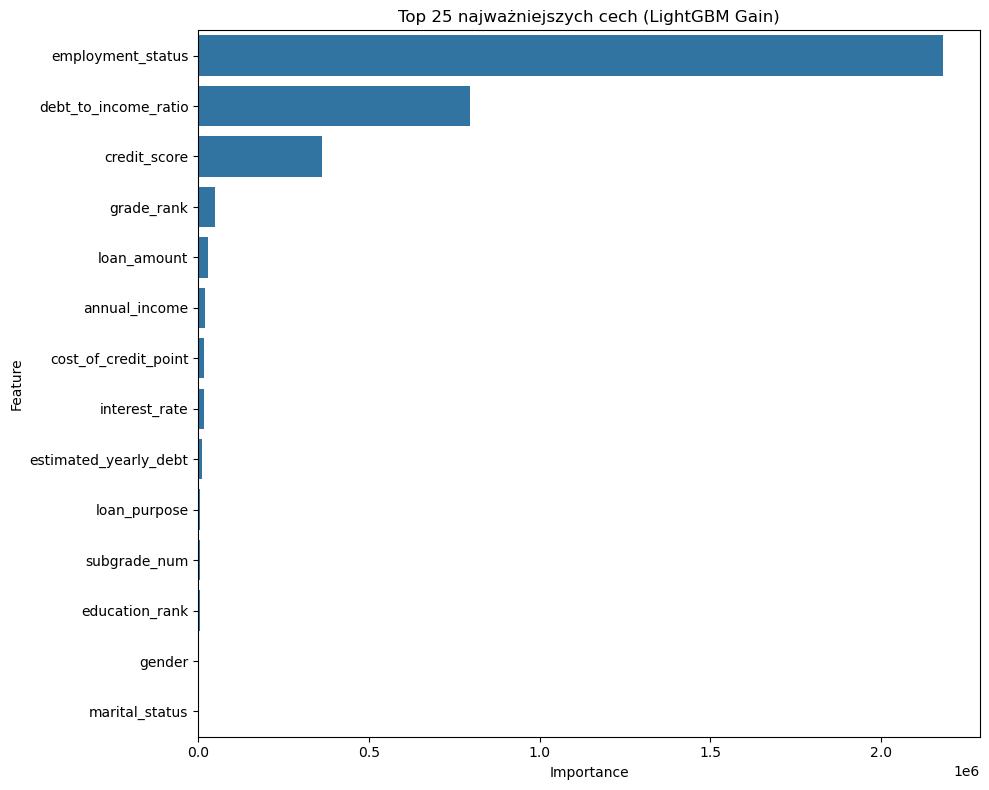

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

def prepare_base_data(df):
    """Minimalne przekształcenia, by model mógł wystartować."""
    df = df.copy()
    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df['education_rank'] = df['education_level'].map(education_ranking)
    
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(float)
    grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
    df['grade_rank'] = df['grade_subgrade'].str[0].map(grade_map)
    cat_columns = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    for col in cat_columns:
        df[col] = df[col].astype('category')
    cols_to_drop = ['id', 'education_level', 'grade_subgrade']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df

# ==========================================
# 2. FABRYKA NOWYCH CECH (Feature Engineering)
# ==========================================
def add_advanced_features(df):
    df = df.copy()

    df['cost_of_credit_point'] = df['interest_rate'] / (df['credit_score'] + 1)

    df['estimated_yearly_debt'] = df['annual_income'] * (df['debt_to_income_ratio'] / 100)
    

    
    return df


def evaluate_model(X, y, categorical_features):
    """Trenuje model w 5-krotnej walidacji i zwraca OOF AUC oraz ważność cech."""
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    oof_preds = np.zeros(len(X))
    feature_importances = np.zeros(X.shape[1])
    
    print(f"Rozpoczynam walidację dla {X.shape[1]} cech...")
    start_time = time.time()
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Szybkie i mocne parametry pod tabele
        model = lgb.LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced' # Pomaga na niezrównoważenie klas
        )
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            categorical_feature=categorical_features,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        # Zapis predykcji
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        
        # Zbieranie feature importance (Gain to lepsza metryka niż liczba podziałów)
        feature_importances += model.booster_.feature_importance(importance_type='gain') / skf.n_splits
        
    cv_auc = roc_auc_score(y, oof_preds)
    elapsed = time.time() - start_time
    
    print(f"Zakończono w {elapsed:.1f} sek. OOF ROC AUC: {cv_auc:.5f}")
    
    # Przygotowanie rankingu cech
    fi_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)
    
    return cv_auc, fi_df


if __name__ == "__main__":

    print("Wczytywanie danych...")

    raw_train = pd.read_csv('../data/train.csv') 
    y = raw_train['loan_paid_back']
    
    cat_cols = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    
    print("\n--- TEST BAZOWY (BASELINE) ---")
    df_base = prepare_base_data(raw_train)
    X_base = df_base.drop(columns=['loan_paid_back'])
    auc_base, fi_base = evaluate_model(X_base, y, cat_cols)
    
    print("\n--- TEST Z NOWYMI CECHAMI (FEATURE ENGINEERING) ---")
    df_advanced = add_advanced_features(df_base)
    X_advanced = df_advanced.drop(columns=['loan_paid_back'])
    auc_advanced, fi_advanced = evaluate_model(X_advanced, y, cat_cols)
    
    print("\n================ PODSUMOWANIE ================")
    print(f"AUC Baza:       {auc_base:.5f}")
    print(f"AUC Nowe Cechy: {auc_advanced:.5f}")
    print(f"Różnica:        {auc_advanced - auc_base:+.5f}")
    
    if auc_advanced > auc_base:
        print("✅ SUKCES! Twoje nowe cechy działają. Zostaw je.")
    else:
        print("❌ PORAŻKA. Nowe cechy wprowadzają szum. Sprawdź Feature Importance i wyrzuć najgorsze.")

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_advanced.head(25))
    plt.title('Top 25 najważniejszych cech (LightGBM Gain)')
    plt.tight_layout()
    plt.show()
    
    zero_imp = fi_advanced[fi_advanced['Importance'] == 0]['Feature'].tolist()
    if zero_imp:
        print(f"\nCechy o zerowym znaczeniu (NATYCHMIAST DO USUNIĘCIA): {zero_imp}")

In [ ]:
def prepare_submission_data_v2(df):
    df = df.copy()
    
    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df['education_rank'] = df['education_level'].map(education_ranking)
    
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)
    grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
    df['grade_rank'] = df['grade_subgrade'].str[0].map(grade_map)

    cat_columns = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    for col in cat_columns:
        df[col] = df[col].astype('category')
 
    cols_to_drop = ['id', 'education_level', 'grade_subgrade']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df

In [8]:
df_base = prepare_submission_data_v2(df)

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = df_base.drop(columns=['loan_paid_back'])
y = df_base['loan_paid_back']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

print("Rozpoczynamy generowanie predykcji OOF dla 3 modeli...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- FOLD {fold+1} ---")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model_lgb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1)
    # Pamietaj, zeby podac cat_features jezeli sa w formacie category!
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]

    model_xgb = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1, enable_categorical=True)
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    
    cat_features_list = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    model_cat = CatBoostClassifier(iterations=500, learning_rate=0.05, random_state=42, thread_count=-1, verbose=0, cat_features=cat_features_list)
    model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    oof_cat[val_idx] = model_cat.predict_proba(X_val)[:, 1]

print("\nPredykcje OOF wygenerowane!")
print(f"OOF AUC LightGBM: {roc_auc_score(y, oof_lgb):.5f}")
print(f"OOF AUC XGBoost:  {roc_auc_score(y, oof_xgb):.5f}")
print(f"OOF AUC CatBoost: {roc_auc_score(y, oof_cat):.5f}")

Rozpoczynamy generowanie predykcji OOF dla 3 modeli...

--- FOLD 1 ---
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932

--- FOLD 2 ---
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Numbe

In [ ]:
# Tworzymy nowy DataFrame, gdzie Cechami są Prawdopodobieństwa z modeli
meta_X = pd.DataFrame({
    'LGBM': oof_lgb,
    'XGB': oof_xgb,
    'CAT': oof_cat
})
meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_X, y)
stacking_preds = meta_model.predict_proba(meta_X)[:, 1]
stacking_auc = roc_auc_score(y, stacking_preds)

print(f"\n🚀 AUC STACKINGU: {stacking_auc:.5f} 🚀")
print("Wagi (współczynniki) przypisane modelom:")
for model_name, coef in zip(meta_X.columns, meta_model.coef_[0]):
    print(f"{model_name}: {coef:.3f}")


🚀 AUC STACKINGU: 0.92156 🚀
Wagi (współczynniki) przypisane modelom:
LGBM: 5.315
XGB: 1.715
CAT: 0.077


In [ ]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 500),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**param)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        preds = model.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
    return np.mean(cv_scores)

print("Rozpoczynam poszukiwania najlepszych hiperparametrów...")
# Tworzymy badanie i celujemy w maksymalizację (direction='maximize')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 

print("\n--- ZAKOŃCZONO ---")
print(f"Najlepsze OOF AUC: {study.best_value:.5f}")
print("Najlepsze parametry:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-03-28 00:25:50,879] A new study created in memory with name: no-name-dae7945d-8fa1-4448-92da-6c78f597cc31


Rozpoczynam poszukiwania najlepszych hiperparametrów...


[I 2026-03-28 00:26:40,865] Trial 0 finished with value: 0.921279375916497 and parameters: {'n_estimators': 436, 'learning_rate': 0.021932215610084262, 'max_depth': 9, 'num_leaves': 44, 'min_child_samples': 208, 'reg_alpha': 0.044115444127007596, 'reg_lambda': 0.6377611043922529, 'subsample': 0.8951535842947672, 'colsample_bytree': 0.635107814661407}. Best is trial 0 with value: 0.921279375916497.
[I 2026-03-28 00:27:46,082] Trial 1 finished with value: 0.9225150799696433 and parameters: {'n_estimators': 781, 'learning_rate': 0.044460553986410245, 'max_depth': 7, 'num_leaves': 107, 'min_child_samples': 367, 'reg_alpha': 0.004492784056818068, 'reg_lambda': 0.34195281689535206, 'subsample': 0.9866730988287318, 'colsample_bytree': 0.9922836496130196}. Best is trial 1 with value: 0.9225150799696433.
[I 2026-03-28 00:28:37,602] Trial 2 finished with value: 0.9225303750689712 and parameters: {'n_estimators': 738, 'learning_rate': 0.056251279235394795, 'max_depth': 5, 'num_leaves': 73, 'min_c


--- ZAKOŃCZONO ---
Najlepsze OOF AUC: 0.92355
Najlepsze parametry:
    'n_estimators': 883,
    'learning_rate': 0.07215875540586067,
    'max_depth': 8,
    'num_leaves': 79,
    'min_child_samples': 439,
    'reg_alpha': 0.12230989377439495,
    'reg_lambda': 0.01652433952477553,
    'subsample': 0.6879714949174074,
    'colsample_bytree': 0.40851406786087663,


In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def objective_xgb(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'random_state': 42,
        'enable_categorical': True,
        'tree_method': 'hist',
        'n_jobs': -1,
        'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 300),
        'gamma': trial.suggest_float('gamma', 1e-4, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**param, early_stopping_rounds=50)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        preds = model.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    return np.mean(cv_scores)

print("Rozpoczynam poszukiwania najlepszych hiperparametrów dla XGBoosta...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30) 

print("\n--- ZAKOŃCZONO TUNING XGBOOST ---")
print(f"Najlepsze OOF AUC: {study_xgb.best_value:.5f}")
print("Najlepsze parametry XGBoost:")
for key, value in study_xgb.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-03-28 00:57:34,917] A new study created in memory with name: no-name-66fd3b31-8f53-45a5-9629-0c8eea6e2a24


Rozpoczynam poszukiwania najlepszych hiperparametrów dla XGBoosta...


[I 2026-03-28 00:59:52,407] Trial 0 finished with value: 0.9212396658474862 and parameters: {'n_estimators': 1084, 'learning_rate': 0.037283288656886786, 'max_depth': 9, 'min_child_weight': 125, 'gamma': 0.020013483891314115, 'reg_alpha': 0.014068333816071487, 'reg_lambda': 0.0035519731287441464, 'subsample': 0.5921853862332443, 'colsample_bytree': 0.5756155840432853}. Best is trial 0 with value: 0.9212396658474862.
[I 2026-03-28 01:01:13,988] Trial 1 finished with value: 0.9186099710261741 and parameters: {'n_estimators': 728, 'learning_rate': 0.01728786313034928, 'max_depth': 5, 'min_child_weight': 74, 'gamma': 0.45758400626151663, 'reg_alpha': 0.7968507681833833, 'reg_lambda': 0.002019287866761584, 'subsample': 0.6403879316248309, 'colsample_bytree': 0.7830031836447796}. Best is trial 0 with value: 0.9212396658474862.
[I 2026-03-28 01:03:29,323] Trial 2 finished with value: 0.9203820251263745 and parameters: {'n_estimators': 952, 'learning_rate': 0.051320751669371126, 'max_depth': 9


--- ZAKOŃCZONO TUNING XGBOOST ---
Najlepsze OOF AUC: 0.92222
Najlepsze parametry XGBoost:
    'n_estimators': 1099,
    'learning_rate': 0.05988334845001533,
    'max_depth': 6,
    'min_child_weight': 89,
    'gamma': 0.001636755574517893,
    'reg_alpha': 0.07616682593289427,
    'reg_lambda': 0.02219254203900335,
    'subsample': 0.9204389358382835,
    'colsample_bytree': 0.4535710403607285,


In [14]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def objective_cat(trial):
    param = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'thread_count': -1,
        
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        
        'depth': trial.suggest_int('depth', 4, 9),
        
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        
        'bootstrap_type': 'Bayesian',
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    # Podajemy kolumny kategoryczne, żeby CatBoost zajął się nimi sam
    cat_features_list = ['gender', 'marital_status', 'employment_status', 'loan_purpose']

    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**param)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            cat_features=cat_features_list,
            early_stopping_rounds=50,
            verbose=False
        )
        
        preds = model.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    return np.mean(cv_scores)

print("Rozpoczynam poszukiwania najlepszych hiperparametrów dla CatBoosta...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=30) 

print("\n--- ZAKOŃCZONO TUNING CATBOOST ---")
print(f"Najlepsze OOF AUC: {study_cat.best_value:.5f}")
print("Najlepsze parametry CatBoost:")
for key, value in study_cat.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-03-28 01:45:43,736] A new study created in memory with name: no-name-0e3de6c3-e46b-46fe-addd-c2c75944aac7


Rozpoczynam poszukiwania najlepszych hiperparametrów dla CatBoosta...


[I 2026-03-28 01:55:06,172] Trial 0 finished with value: 0.918738616396479 and parameters: {'iterations': 728, 'learning_rate': 0.07253286452759225, 'depth': 6, 'l2_leaf_reg': 5.024293684878129, 'random_strength': 0.07487618445579003, 'bagging_temperature': 0.8392815715517815, 'border_count': 130}. Best is trial 0 with value: 0.918738616396479.
[I 2026-03-28 02:05:04,521] Trial 1 finished with value: 0.9153802113464338 and parameters: {'iterations': 1433, 'learning_rate': 0.020725424084471915, 'depth': 4, 'l2_leaf_reg': 1.3056852559225882, 'random_strength': 8.175994881814349, 'bagging_temperature': 0.6603874366954295, 'border_count': 225}. Best is trial 0 with value: 0.918738616396479.
[I 2026-03-28 02:12:02,461] Trial 2 finished with value: 0.914804634900259 and parameters: {'iterations': 556, 'learning_rate': 0.04729636875508652, 'depth': 7, 'l2_leaf_reg': 6.232809576378423, 'random_strength': 0.01391876236523165, 'bagging_temperature': 0.708300543692163, 'border_count': 37}. Best i

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


lgb_params = {
    'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt',
    'random_state': 42, 'n_jobs': -1,
    'n_estimators': 883,
    'learning_rate': 0.07215875540586067,
    'max_depth': 8,
    'num_leaves': 79,
    'min_child_samples': 439,
    'reg_alpha': 0.12230989377439495,
    'reg_lambda': 0.01652433952477553,
    'subsample': 0.6879714949174074,
    'colsample_bytree': 0.40851406786087663
}

xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': 'auc', 
    'random_state': 42, 'n_jobs': -1,
    'enable_categorical': True, 'tree_method': 'hist',
    'n_estimators': 1099,
    'learning_rate': 0.05988334845001533,
    'max_depth': 6,
    'min_child_weight': 89,
    'gamma': 0.001636755574517893,
    'reg_alpha': 0.07616682593289427,
    'reg_lambda': 0.02219254203900335,
    'subsample': 0.9204389358382835,
    'colsample_bytree': 0.4535710403607285
}

cat_params = {
    'loss_function': 'Logloss', 'eval_metric': 'AUC',
    'random_seed': 42, 'thread_count': -1, 'verbose': False,
    'bootstrap_type': 'Bayesian',
    'iterations': 1176,
    'learning_rate': 0.0411659297782639,
    'depth': 8,
    'l2_leaf_reg': 18.976642177265127,
    'random_strength': 0.0016250354947837794,
    'bagging_temperature': 0.36215545821644324,
    'border_count': 190
}

cat_features_list = ['gender', 'marital_status', 'employment_status', 'loan_purpose']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Miejsce na predykcje treningowe
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))



print("Rozpoczynam finalny trening Stacking OOF...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- FOLD {fold+1}/5 ---")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print("Trenowanie LightGBM...")
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]    

    print("Trenowanie XGBoost...")
    model_xgb = xgb.XGBClassifier(**xgb_params, early_stopping_rounds=50)
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]

    print("Trenowanie CatBoost...")
    model_cat = CatBoostClassifier(**cat_params)
    model_cat.fit(X_train, y_train, eval_set=[(X_val, y_val)], cat_features=cat_features_list, early_stopping_rounds=50)
    oof_cat[val_idx] = model_cat.predict_proba(X_val)[:, 1]

print("\n--- TRENING ZAKOŃCZONY ---")
print(f"OOF AUC LGBM: {roc_auc_score(y, oof_lgb):.5f}")
print(f"OOF AUC XGB:  {roc_auc_score(y, oof_xgb):.5f}")
print(f"OOF AUC CAT:  {roc_auc_score(y, oof_cat):.5f}")
print("\nTrenowanie Meta-Modelu (LogReg)...")
meta_X_train = pd.DataFrame({'LGBM': oof_lgb, 'XGB': oof_xgb, 'CAT': oof_cat})

meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_X_train, y)

stacking_preds = meta_model.predict_proba(meta_X_train)[:, 1]
final_auc = roc_auc_score(y, stacking_preds)

print(f"\n🏆 OSTATECZNY WYNIK OOF AUC (STACKING): {final_auc:.5f} 🏆")
print("Wagi modeli:")
for model_name, coef in zip(meta_X_train.columns, meta_model.coef_[0]):
    print(f"{model_name}: {coef:.3f}")

Rozpoczynam finalny trening Stacking OOF...

--- FOLD 1/5 ---
Trenowanie LightGBM...
Trenowanie XGBoost...
Trenowanie CatBoost...

--- FOLD 2/5 ---
Trenowanie LightGBM...
Trenowanie XGBoost...
Trenowanie CatBoost...

--- FOLD 3/5 ---
Trenowanie LightGBM...
Trenowanie XGBoost...
Trenowanie CatBoost...

--- FOLD 4/5 ---
Trenowanie LightGBM...
Trenowanie XGBoost...
Trenowanie CatBoost...

--- FOLD 5/5 ---
Trenowanie LightGBM...
Trenowanie XGBoost...
Trenowanie CatBoost...

--- TRENING ZAKOŃCZONY ---
OOF AUC LGBM: 0.92354
OOF AUC XGB:  0.92221
OOF AUC CAT:  0.92051

Trenowanie Meta-Modelu (LogReg)...

🏆 OSTATECZNY WYNIK OOF AUC (STACKING): 0.92355 🏆
Wagi modeli:
LGBM: 4.945
XGB: 1.716
CAT: 0.379


In [19]:
print(f"\n🏆 OSTATECZNY WYNIK OOF AUC (STACKING): {final_auc:.5f} 🏆")


🏆 OSTATECZNY WYNIK OOF AUC (STACKING): 0.92355 🏆


In [ ]:
import pandas as pd
import numpy as np

def prepare_base_data(df):
    df = df.copy()
    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df['education_rank'] = df['education_level'].map(education_ranking)
    
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(float)
    grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
    df['grade_rank'] = df['grade_subgrade'].str[0].map(grade_map)
    
    cat_columns = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    for col in cat_columns:
        df[col] = df[col].astype('category')
        
    cols_to_drop = ['id', 'education_level', 'grade_subgrade']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df

print("Wczytywanie i przygotowywanie zbioru testowego...")
test_raw = pd.read_csv('../data/test.csv')

test_ids = test_raw['id'].copy()

X_test = prepare_base_data(test_raw)

X_test = X_test[X.columns]

print(f"Liczba kolumn w Train (X): {X.shape[1]}")
print(f"Liczba kolumn w Test (X_test): {X_test.shape[1]}")

print("\nGenerowanie predykcji dla zbioru testowego (Base Models)...")

preds_test_lgb = model_lgb.predict_proba(X_test)[:, 1]
preds_test_xgb = model_xgb.predict_proba(X_test)[:, 1]
preds_test_cat = model_cat.predict_proba(X_test)[:, 1]

print("\nŁączenie predykcji przez Meta-Model...")
meta_X_test = pd.DataFrame({
    'LGBM': preds_test_lgb,
    'XGB': preds_test_xgb,
    'CAT': preds_test_cat
})

final_test_preds = meta_model.predict_proba(meta_X_test)[:, 1]

print("Zapisywanie pliku CSV...")
submission = pd.DataFrame({
    'id': test_ids,
    'loan_paid_back': final_test_preds
})

submission.to_csv('..//submissions/28.03_stacking_submission_clean.csv', index=False)
print("✅ Sukces! Plik 'final_stacking_submission_clean.csv' jest czysty, bez szumu i gotowy na Kaggle!")

Wczytywanie i przygotowywanie zbioru testowego...
Liczba kolumn w Train (X): 12
Liczba kolumn w Test (X_test): 12

Generowanie predykcji dla zbioru testowego (Base Models)...

Łączenie predykcji przez Meta-Model...
Zapisywanie pliku CSV...
✅ Sukces! Plik 'final_stacking_submission_clean.csv' jest czysty, bez szumu i gotowy na Kaggle!
